In [141]:
import random
from statistics import mean
from typing import Literal
from pprint import pprint

from sklearn.decomposition import PCA
from tqdm.notebook import trange, tqdm
import numpy as np
from torchvision.datasets import CIFAR10, FashionMNIST, MNIST
from torchvision.transforms.v2 import (
    GaussianNoise, Compose, ToTensor, GaussianBlur, RandomRotation, RandomHorizontalFlip, RandomVerticalFlip, RandomCrop, RandomAffine, Pad, Lambda
)
from torchvision.transforms.v2.functional import gaussian_noise
from torch.utils.data import DataLoader, ConcatDataset, Dataset, random_split, WeightedRandomSampler, Subset, TensorDataset, random_split
from torch import nn
import torch
from matplotlib import pyplot as plt

data_dir = '~/DataScience/datasets/'

## Solution 2

In [83]:
def salt_and_pepper_noise(image: torch.Tensor) -> torch.Tensor:
    p = 0.05    # noise probability
    mask = torch.randn(image.shape)
    image[mask < p * 0.5] = 1         # salt
    image[1-mask < (1-p) * 0.5] = 0   # pepper
    return image

all_transforms = {
    'original': [nn.Identity()],
    'gaussian_noise': [GaussianNoise(0, 0.05, clip=True)],
    'salt_and_pepper_noise': [Lambda(salt_and_pepper_noise)],
    'rotate30': [RandomRotation(degrees=30)],
    'horizontal_flip': [RandomHorizontalFlip(p=1.0)],
    'vertical_flip': [RandomVerticalFlip(p=1.0)],
    'translate': [RandomAffine(degrees=0, translate=(0.2, 0.15))],
    'gaussian_blur': [GaussianBlur(kernel_size=3, sigma=1.5)],
    'crop': [Pad(4), RandomCrop(32)],
}

transformed_datasets = [CIFAR10(data_dir, transform=Compose([ToTensor()] + t)) for t in all_transforms.values()]
augmented_dataloader = DataLoader(ConcatDataset(transformed_datasets))

/home/sohangchopra/DataScience/iit-madras-web-mtech-ai/.venv/lib64/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/sohangchopra/DataScience/iit-madras-web-mtech-ai/.venv/lib64/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


KeyboardInterrupt: 

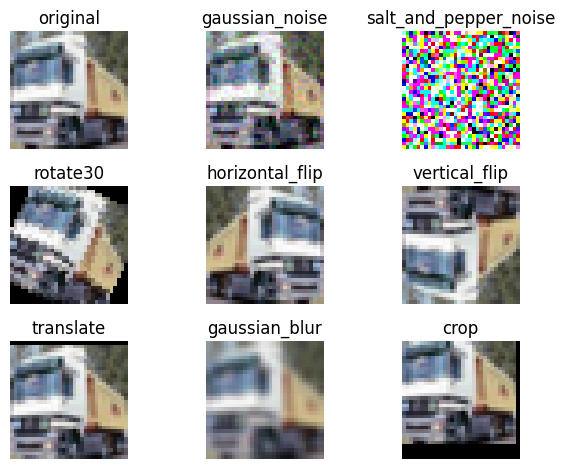

In [ ]:
names = list(all_transforms.keys())
image_index = 1
dpi = 80
fig, axes = plt.subplots(3, 3)    # CIFAR images have shape (32,32)
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        i = 3 * row + col
        image, _label = transformed_datasets[i][image_index]
        ax.imshow(image.permute(1,2,0))     # convert (C,H,W) (torch tensor format) -> (H,W,C) (matplotlib format) where H,W,C are image height,width,channels
        ax.set_title(names[i])
        ax.set_axis_off()
fig.tight_layout()

## Solution 3

In [ ]:
loss_fn = nn.CrossEntropyLoss()
batch_size = 64
epochs = 5

In [ ]:
train_ds = FashionMNIST(data_dir, download=True, train=True, transform=ToTensor())
valid_ds = FashionMNIST(data_dir, download=True, train=False, transform=ToTensor())
valid_loader = DataLoader(valid_ds, batch_size=batch_size)

/home/sohangchopra/DataScience/iit-madras-web-mtech-ai/.venv/lib64/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [ ]:
generator = torch.Generator().manual_seed(42)
subsets = [Subset(train_ds, indices=torch.randint(len(train_ds), size=(38_400,), generator=generator)) for _ in range(3)]

In [ ]:
def train(model, train_loader) -> None:
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(epochs):
        print('Epoch', epoch)
        for images, labels in tqdm(train_loader):
            optimizer.zero_grad()
            output_logits = model(torch.flatten(images, start_dim=1))
            loss = loss_fn(output_logits, labels)
            loss.backward()       # gradient calculation
            optimizer.step()      # update weights

def evaluate(model, output_mode: Literal['soft', 'hard']) -> float:
    """@param output_mode: 'soft' -> model outputs logits, 'hard' -> model directly outputs labels."""
    correct_predictions = 0
    with torch.no_grad():
        for images, labels in tqdm(valid_loader):
            outputs = model(torch.flatten(images, start_dim=1))
            if output_mode == 'soft':     # get output label indices (i.e. where output logits are maximum)
                outputs = torch.argmax(outputs, dim=1)
            correct_predictions += (outputs == labels).sum()
    accuracy = correct_predictions / len(valid_ds)
    return accuracy

In [ ]:
models = []
for i, subset in enumerate(subsets):
    print('Subset', i)
    model = nn.Sequential(
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10),
        # Softmax NOT added, becuase CrossEntropy loss already internally applies it
    )
    train_loader = DataLoader(subset, batch_size=batch_size)
    train(model, train_loader)
    print('Evaluating trained model...')
    accuracy = evaluate(model, output_mode='soft')
    print('Accuracy:', accuracy)
    models.append(model)
    

Subset 0
Epoch 0


  0%|          | 0/600 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/600 [00:00<?, ?it/s]

Epoch 2


...

Epoch 4


  0%|          | 0/600 [00:00<?, ?it/s]

Evaluating trained model...


  0%|          | 0/157 [00:00<?, ?it/s]

Accuracy: tensor(0.8540)


In [ ]:
def ensemble_model(X: torch.Tensor) -> torch.Tensor:
    """Ensemble of the 3 bootstrap models. Majority-Choice voting, tie-breaker: random output class."""
    stacked_output_indices = torch.stack([torch.argmax(model(X), dim=1) for model in models], dim=0)  # model(X): logits, argmax(): output label indices
    
    # shuffle - if all 3 models disagree, then "winner" is random
    permutation = torch.randperm(stacked_output_indices.size(0), generator=generator)
    shuffled_outputs = stacked_output_indices[permutation]
    
    mode = torch.mode(shuffled_outputs, dim=0)
    return mode.values         # answer label indices

evaluate(ensemble_model, output_mode='hard')

  0%|          | 0/157 [00:00<?, ?it/s]

tensor(0.8683)

Summary of accuracies:
* Model of random sample 1: 86.03%
* Model of random sample 2: 86.08%
* Model of random sample 3: 85.04%
* Ensemble (Majority-Choice voting, random winnner if no majority): 86.83%

Therefore the Ensemble model is more accurate than the 3 weaker models trained on bootstrap samples.

## Solution 4

In [ ]:
# run on Colab GPU
np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device=}')

# NOTE: pin_memory=True speeds up GPU <-> CPU transfer
batch_size = 64
valid_ds = FashionMNIST(data_dir, train=False, download=True, transform=Compose([ToTensor(), Lambda(torch.flatten)]))
valid_loader = DataLoader(valid_ds, batch_size=batch_size, pin_memory=True)
train_ds = FashionMNIST(data_dir, train=True, download=True, transform=Compose([ToTensor(), Lambda(torch.flatten)]))
train_indices = np.random.choice(len(train_ds), size=len(train_ds) // 10, replace=False)    # use random 10% of train data
train_loader = DataLoader(Subset(train_ds, train_indices), batch_size=batch_size, pin_memory=True)

loss_fn = nn.CrossEntropyLoss()
val_losses = {}
for lambda_l2 in (0, 1e-4, 1e-2):
    model = nn.Sequential(
        nn.Linear(784, 1024),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.ReLU(),
        nn.Linear(512,  256),
        # Softmax omitted because CrossEntropy() loss already applies softmax internally
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=lambda_l2)
    val_losses[lambda_l2] = []

    for epoch in trange(50):
        # train
        for flat_images, labels in train_loader:
            flat_images, labels = flat_images.to(device), labels.to(device)
            optimizer.zero_grad()
            train_logits = model(flat_images)
            train_loss = loss_fn(train_logits, labels)
            train_loss.backward()    # calculate gradients
            optimizer.step()         # update gradients

        # validate loss for current epoch
        with torch.no_grad():
            val_losses[lambda_l2].append(sum(loss_fn(model(flat_images.to(device)), labels.to(device)).item() for flat_images, labels in valid_loader))

In [ ]:
for lambda_l2, losses in val_losses.items():
    print(lambda_l2, ':', losses)

0 : [98.92598485946655, 88.58213619887829, 80.48260951042175, 78.17220948636532, 76.82968936860561, 74.24351179599762, 76.73381425440311, 76.45830515027046, 76.052694901824, 77.72112725675106, 80.178028896451, 84.54308646917343, 86.88021646440029, 83.07989498972893, 82.69062468409538, 83.67063826322556, 82.0132769793272, 82.4757432937622, 84.6782878190279, 80.82330471277237, 85.20622020959854, 91.86587971448898, 94.75947512686253, 97.26977349817753, 103.16528235375881, 97.30009017884731, 99.841702029109, 100.69867281615734, 99.0071686655283, 101.41863395273685, 106.00812734663486, 112.42008255422115, 113.2115945070982, 122.72690963745117, 107.29359428584576, 111.83331288397312, 109.95935502648354, 108.74853794276714, 123.14524433016777, 122.27230510115623, 118.87612208724022, 116.24187672138214, 125.96682420372963, 121.95011837780476, 121.10328881442547, 117.84693868458271, 124.3808453977108, 116.32180857658386, 117.63213582336903, 125.02571494877338]
0.0001 : [93.90749743580818, 86.85

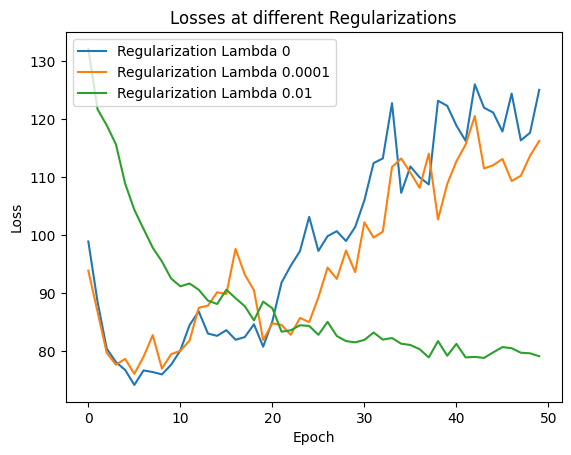

In [ ]:
for lambda_l2, losses in val_losses.items():
    plt.plot(losses, label=f'Regularization Lambda {lambda_l2}')
plt.title('Losses at different Regularizations')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

* Around epoch 5, unregularized model hit least loss and then increased loss, suggesting overfitting after that.
* Regularization parameter $\lambda = 10^{-4}$ also overfit, but its final loss is less. 
* But regulariztion with $\lambda = 10^{-2}$ is much better as it didn't overfit at all: it started off with a higher validation loss but reduced more gradually to a much lower final loss.

## Solution 6

In [ ]:
def train(model, loss_fn, epochs) -> None:
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    for epoch in trange(epochs):
        for flat_images, labels in train_loader:
            optimizer.zero_grad()
            logits = model(flat_images)
            loss = loss_fn(flat_images, logits, labels)
            loss.backward()
            optimizer.step()

def mk_student_model():
    return nn.Sequential(
        nn.Linear(784, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
        # Softmax omitted as it's handled in loss function
    )

def evaluate_accuracy(model) -> float:
    with torch.no_grad():
        print('Evaluating...')
        correct_predictions = 0
        for flat_images, labels in valid_loader:
            logits = model(flat_images)
            outputs = torch.argmax(logits, dim=1)
            correct_predictions += (outputs == labels).sum()
        return correct_predictions / len(valid_ds)

def distilled_loss(flat_images, student_logits, labels):
    l_ce = cross_entropy(student_logits, labels)

    # Knowledge Distillation loss
    with torch.no_grad():
        teacher_logits = teacher_model(flat_images)
    teacher_probabs = nn.functional.softmax(teacher_logits / temperature, dim=1)
    student_log_probabs = nn.functional.log_softmax(student_logits / temperature, dim=1)
    l_kd = kl_divergence(student_log_probabs, teacher_probabs) * (temperature ** 2)

    return alpha * l_ce + (1 - alpha) * l_kd

In [ ]:
batch_size = 64
transform = Compose([ToTensor(), Lambda(torch.flatten)])
train_ds = MNIST(data_dir, train=True, download=True, transform=transform)
valid_ds = MNIST(data_dir, train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=batch_size)
valid_loader = DataLoader(valid_ds, batch_size=batch_size)

teacher_model = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
    # Softmax omitted because CrossEntropy() loss adds an implicit Softmax
)
cross_entropy = nn.CrossEntropyLoss()
train(teacher_model, lambda _flat_images, logits, labels: cross_entropy(logits, labels), epochs=5)
print('Teacher Model:', evaluate_accuracy(teacher_model))

/home/sohangchopra/DataScience/iit-madras-web-mtech-ai/.venv/lib64/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


  0%|          | 0/5 [00:00<?, ?it/s]

Evaluating...
Teacher Model: tensor(0.9174)


In [ ]:
student_model_direct = mk_student_model()
train(student_model_direct, lambda _flat_images, logits, labels: cross_entropy(logits, labels), epochs=5)
print('Student Model without Teacher Model:', evaluate_accuracy(student_model_direct))

  0%|          | 0/5 [00:00<?, ?it/s]

Evaluating...
Student Model without Teacher Model: tensor(0.9121)


In [ ]:
alpha, temperature = 0.5, 3         # used in distilled loss
kl_divergence = nn.KLDivLoss(reduction="batchmean")    # used in distilled loss
student_model_distilled = mk_student_model()
train(student_model_distilled, distilled_loss, epochs=20)
print('Student Model with Knowledge Distillation:', evaluate_accuracy(student_model_distilled))

  0%|          | 0/20 [00:00<?, ?it/s]

Evaluating...
Student Model with Knowledge Distillation: tensor(0.9239)


Accuracies (all models trained for 5 epochs):
* Teacher Model: 91.74%
* Student Model without a teacher model: 91.21%
* Student Model with Knowledge Distillation: 92.39%

So distillation loss using teacher's model helped student model learn better.

## Solution 8

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

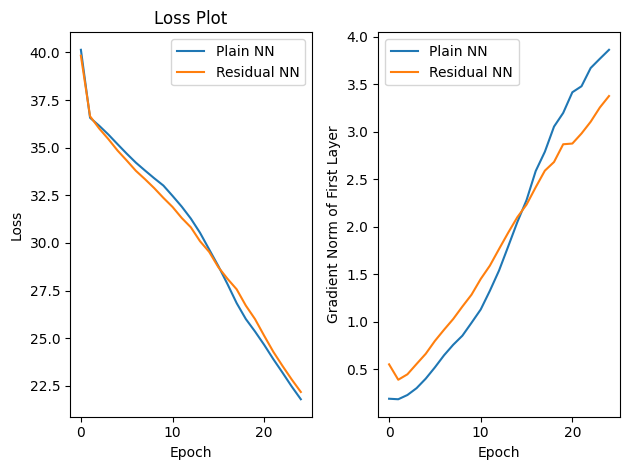

In [97]:
input_features = 20
train_size = 1024
generator = torch.Generator().manual_seed(42)
X = torch.rand(size=(train_size, input_features), generator=generator)
w = torch.rand(size=(input_features,), generator=generator)
error = torch.normal(0, 1, size=(train_size,), generator=generator)
y = (torch.sin(w @ X.T) + error).unsqueeze(1)

batch_size = 32
train_ds = TensorDataset(X, y)
train_loader = DataLoader(train_ds, batch_size=batch_size)

loss_fn = nn.MSELoss()

def train(model, first_layer):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_losses = []
    fst_gradient_norm_means = []
    for _epoch in trange(25):
        epoch_fst_gradient_norms = []
        epoch_loss = 0
        for x, y in train_loader:      # loop over batches  
            optimizer.zero_grad()
            probabs = model(x)
            loss = loss_fn(probabs, y)
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
            epoch_fst_gradient_norms.append(torch.linalg.norm(first_layer.weight.grad))
        fst_gradient_norm_means.append(sum(epoch_fst_gradient_norms) / len(epoch_fst_gradient_norms))
        train_losses.append(epoch_loss)
    return train_losses, fst_gradient_norm_means

plain_nn = nn.Sequential(
    nn.Linear(20, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
)
plain_losses, plain_fst_gradient_norms = train(plain_nn, plain_nn[0])

class ResidualModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(20, 64)
        self.layer2 = nn.Linear(64, 64)
        self.layer3 = nn.Linear(64, 64)
        self.output_layer = nn.Linear(64, 1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out1 = torch.relu(self.layer1(x))
        out2 = torch.relu(self.layer2(out1))
        out3 = torch.relu(self.layer3(out2) + out1)    # skip connection: layer 1 -> layer 3 (outputs added)
        return self.output_layer(out3)
    
residual_nn = ResidualModel()
residual_losses, residual_fst_gradient_norms = train(residual_nn, residual_nn.layer1) 

fig, axes = plt.subplots(1,2)
axes[0].plot(plain_losses, label='Plain NN')
axes[0].plot(residual_losses, label='Residual NN')
axes[0].set_title('Loss Plot')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(plain_fst_gradient_norms, label='Plain NN')
axes[1].plot(residual_fst_gradient_norms, label='Residual NN')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Gradient Norm of First Layer')
axes[1].legend()
fig.tight_layout()

Both models follow similar loss curves over epochs. 
During initial epochs, residual model has higher gradient norm of first layer than plain model - this is as expected since skip connection is supposed to solve Vanishing Gradients problem.

## Solution 9

/home/sohangchopra/DataScience/iit-madras-web-mtech-ai/.venv/lib64/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Epoch 0: Train Loss = 42.42392585426569, Validation Loss = 3.186341792345047
Epoch 1: Train Loss = 15.658435076475143, Validation Loss = 2.398679781705141
Epoch 2: Train Loss = 10.852599125355482, Validation Loss = 2.456479698419571
Epoch 3: Train Loss = 8.451162634417415, Validation Loss = 2.0427272878587246
Epoch 4: Train Loss = 7.185229612514377, Validation Loss = 2.1917127780616283
Epoch 5: Train Loss = 6.8324810694903135, Validation Loss = 2.248849578201771
Epoch 6: Train Loss = 5.437407599762082, Validation Loss = 2.211504576727748
Epoch 7: Train Loss = 4.967198572587222, Validation Loss = 2.373322421684861
Epoch 8: Train Loss = 4.089640903752297, Validation Loss = 2.8376810075715184
Early Stopping since valid_losses[f8] (2.8376810075715184) >= valid_losses[f3] (2.0427272878587246)


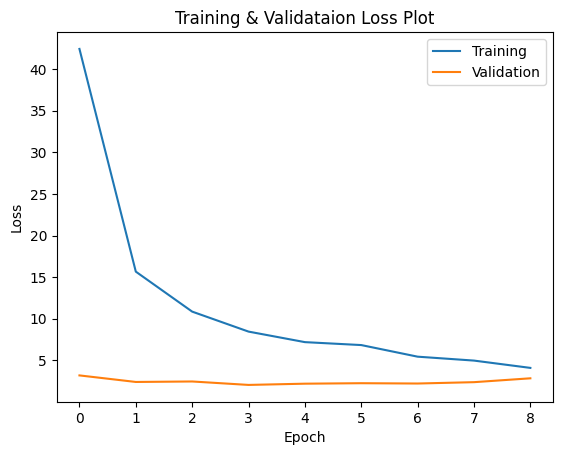

In [ ]:
train_ds = MNIST(data_dir, train=True, transform=Compose([ToTensor(), Lambda(torch.flatten)]), download=True)
valid_ds = MNIST(data_dir, train=False, transform=Compose([ToTensor(), Lambda(torch.flatten)]), download=True)
train_loader = DataLoader(train_ds, batch_size=512)
valid_loader = DataLoader(valid_ds, batch_size=512)

model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128,  64),
    nn.ReLU(),
    nn.Linear( 64,  10),
    # implicit Softmax at end due to cross entropy loss
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

patience = 5     # epochs
train_losses = []
valid_losses = []
best_epoch = 0
for epoch in range(100):
    # train
    epoch_train_loss = 0
    for flat_images, labels in train_loader:
        optimizer.zero_grad()
        logits = model(flat_images)
        loss = loss_fn(logits, labels)
        epoch_train_loss += loss.item()
        loss.backward()
        optimizer.step()
    train_losses.append(epoch_train_loss)

    # validate
    with torch.no_grad():
        valid_losses.append(sum(loss_fn(model(flat_images), labels).item() for flat_images, labels in valid_loader))
    
    print(f'Epoch {epoch}: Train Loss = {train_losses[epoch]}, Validation Loss = {valid_losses[epoch]}')

    if valid_losses[epoch] < valid_losses[best_epoch]:
        best_epoch = epoch
    elif epoch - best_epoch >= patience:
        print(f'Early Stopping since valid_losses[f{epoch}] ({valid_losses[epoch]}) >= valid_losses[{best_epoch}] ({valid_losses[best_epoch]})')
        break

plt.plot(train_losses, label='Training')
plt.plot(valid_losses, label='Validation')
plt.title('Training & Validataion Loss Plot')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Solution 12

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

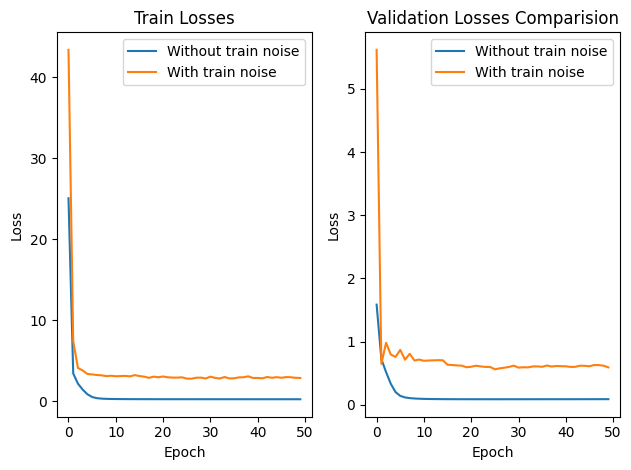

In [131]:
N = 2000
batch_size = 64
num_features = 10
generator = torch.Generator().manual_seed(42)
X = torch.rand(size=(N,num_features), generator=generator)
w = torch.rand(size=(num_features,), generator=generator)
e = torch.normal(0, 0.1, size=(N,), generator=generator)
y = (X @ w + e).unsqueeze(1)
train_ds, valid_ds = random_split(TensorDataset(X, y), [0.8, 0.2], generator=generator)
train_loader = DataLoader(train_ds, batch_size=batch_size)
valid_loader = DataLoader(valid_ds, batch_size=batch_size)

loss_fn = nn.MSELoss()

def train(add_train_noise: bool) -> tuple[list[float], list[float]]:
    model = nn.Sequential(
        nn.Linear(10, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_losses = []
    valid_losses = []

    for _epoch in trange(50):
        # train
        epoch_train_loss = 0
        for x, y in train_loader:
            optimizer.zero_grad()
            if add_train_noise:
                x += torch.normal(0, 0.5, size=x.shape)
            outputs = model(x)
            loss = loss_fn(outputs, y)
            epoch_train_loss += loss.item()
            loss.backward()
            optimizer.step()
        train_losses.append(epoch_train_loss)

        # validate
        with torch.no_grad():
            valid_losses.append(sum(loss_fn(model(x), y) for x, y in valid_loader))

    return train_losses, valid_losses

normal_train_losses, normal_valid_losses = train(add_train_noise=False)
noisy_train_losses, noisy_valid_losses = train(add_train_noise=True)

fig, axes = plt.subplots(1,2)
axes[0].plot(normal_train_losses, label="Without train noise")
axes[0].plot(noisy_train_losses, label="With train noise")
axes[0].set_title("Train Losses")
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(normal_valid_losses, label='Without train noise')
axes[1].plot(noisy_valid_losses, label="With train noise")
axes[1].set_title('Validation Losses Comparision')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
fig.tight_layout()

Without noise, loss quickly becomes 0 as relationship between x and y is very simple (linear with noise).
With noise, losses (training & validation) are initially much more, then settle down to more than without noise by almost a constant. 
Also unlike the model without noise, model with noise has a few "spikes" in validataion loss curve before settling down to minimum.

## Solution 14

In [142]:
N, num_features = 6000, 50
torch.manual_seed(42)
X = -1 + 2 * torch.rand(size=(N, num_features))
w = -1 + 2 * torch.rand(size=(num_features,))
v = -1 + 2 * torch.rand(size=(num_features,))
# Convert sign {-1, 1} to {0, 1} for BCELoss
y = ((torch.sign(X @ w + 0.5 * torch.sin(X @ v)) + 1) / 2).unsqueeze(1)

dataset = TensorDataset(X, y)
train_size = int(0.8 * N)
test_size = N - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=512)

def get_model():
    return nn.Sequential(
        nn.Linear(50, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 1),
        nn.Sigmoid()
    )

def flatten_params(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()]).clone()

def run_experiment(opt_type):
    model = get_model()
    loss_fn = nn.BCELoss()
    
    if opt_type == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    elif opt_type == 'Nesterov':
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)
    elif opt_type == 'L-BFGS':
        # L-BFGS requires a closure and usually full-batch or large batch
        optimizer = torch.optim.LBFGS(model.parameters(), lr=1, history_size=10)

    history = {'loss': [], 'grad_norm': [], 'update_mag': [], 'params': []}
    
    for epoch in range(15):
        epoch_loss = 0
        model.train()
        
        for batch_x, batch_y in train_loader:
            old_params = flatten_params(model)
            
            def closure():
                optimizer.zero_grad()
                output = model(batch_x)
                loss = loss_fn(output, batch_y)
                if loss.requires_grad:
                    loss.backward()
                return loss

            if opt_type == 'L-BFGS':
                loss = optimizer.step(closure)
            else:
                optimizer.zero_grad()
                output = model(batch_x)
                loss = loss_fn(output, batch_y)
                loss.backward()
                optimizer.step()

            # Record metrics
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.data.norm(2).item()**2
            
            new_params = flatten_params(model)
            history['update_mag'].append(torch.norm(new_params - old_params).item())
            history['grad_norm'].append(total_norm**0.5)
            epoch_loss += loss.item()
        
        history['loss'].append(epoch_loss / len(train_loader))
        history['params'].append(flatten_params(model).numpy())

    # Test Accuracy
    model.eval()
    correct = 0
    with torch.no_grad():
        for bx, by in test_loader:
            preds = (model(bx) > 0.5).float()
            correct += (preds == by).sum().item()
    accuracy = correct / test_size
    
    return history, accuracy

# Run experiments
results = {}
for opt in ['SGD', 'Nesterov', 'L-BFGS']:
    results[opt] = run_experiment(opt)

In [150]:
print('Accuracies:', {opt: acc for opt, (history, acc) in results.items()})

Accuracies: {'SGD': 0.4766666666666667, 'Nesterov': 0.8675, 'L-BFGS': 0.3275}


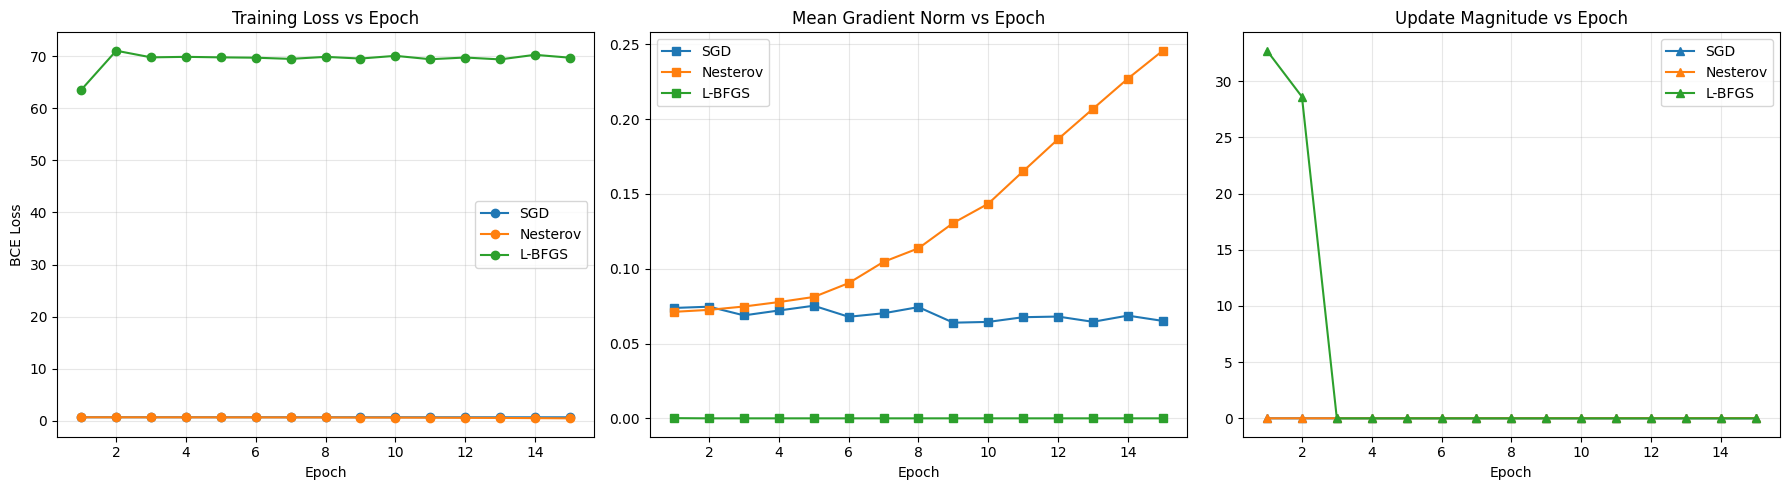

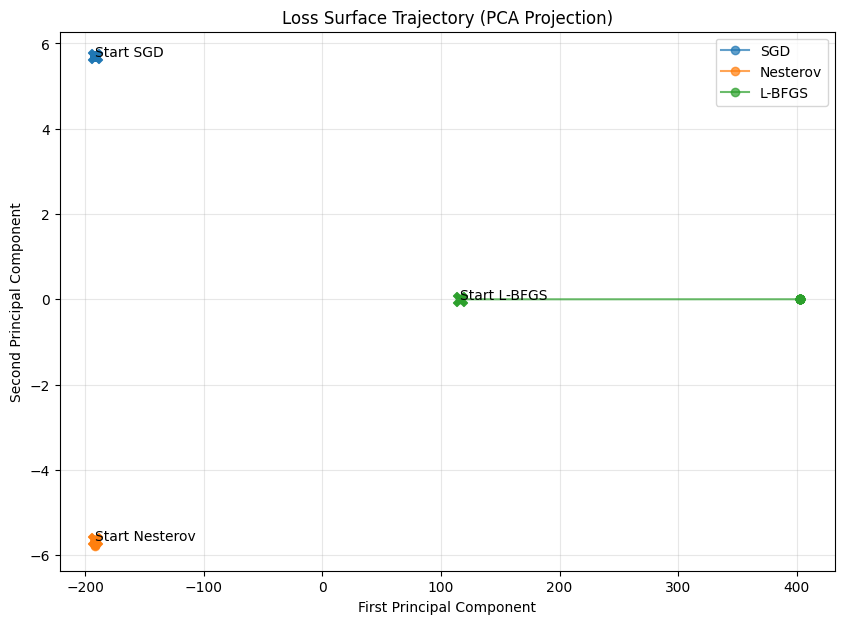

In [149]:
def plot_optimization_results(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = np.arange(1, 16)
    
    for label, (history, _) in results.items():
        # 1. Training Loss
        axes[0].plot(epochs_range, history['loss'], label=label, marker='o')
        axes[0].set_title("Training Loss vs Epoch")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("BCE Loss")
        
        # 2. Gradient Norm (averaged per epoch for plotting)
        # Note: history['grad_norm'] contains per-batch data
        batches_per_epoch = len(history['grad_norm']) // 15
        epoch_grad_norms = [np.mean(history['grad_norm'][i*batches_per_epoch:(i+1)*batches_per_epoch]) 
                           for i in range(15)]
        axes[1].plot(epochs_range, epoch_grad_norms, label=label, marker='s')
        axes[1].set_title("Mean Gradient Norm vs Epoch")
        axes[1].set_xlabel("Epoch")
        
        # 3. Parameter Update Magnitude
        epoch_updates = [np.mean(history['update_mag'][i*batches_per_epoch:(i+1)*batches_per_epoch]) 
                        for i in range(15)]
        axes[2].plot(epochs_range, epoch_updates, label=label, marker='^')
        axes[2].set_title("Update Magnitude vs Epoch")
        axes[2].set_xlabel("Epoch")

    for ax in axes:
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # --- PCA Trajectory Plot ---
    plt.figure(figsize=(10, 7))
    
    # Combine all parameters to fit a common PCA space
    all_params = []
    for label in results:
        all_params.extend(results[label][0]['params'])
    
    pca = PCA(n_components=2)
    pca.fit(np.array(all_params))
    
    for label, (history, _) in results.items():
        coords = pca.transform(np.array(history['params']))
        plt.plot(coords[:, 0], coords[:, 1], '-o', label=label, alpha=0.7)
        # Mark start and end
        plt.scatter(coords[0, 0], coords[0, 1], marker='X', s=100) 
        plt.annotate(f"Start {label}", (coords[0, 0], coords[0, 1]))

    plt.title("Loss Surface Trajectory (PCA Projection)")
    plt.xlabel("First Principal Component")
    plt.ylabel("Second Principal Component")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_optimization_results(results)

In this case **Nesterov Momentum** is the only successful optimizer, while **L-BFGS** and **SGD** failed to converge effectively within the 15-epoch limit.

| Metric | SGD | Nesterov | L-BFGS |
| :--- | :--- | :--- | :--- |
| **Convergence** | **Stalled.** Loss and gradients remain flat. | **Fast/Efficient.** Steady loss reduction. | **Failed.** Single massive jump, then flatlines. |
| **Stability** | **High but stagnant.** No movement. | **Stable Acceleration.** Increasing gradients. | **Unstable.** Catastrophic initial update. |
| **Final Accuracy** | **47.67%** (Random) | **86.75%** (Success) | **32.75%** (Broken) |

#### Curvature in L-BFGS
L-BFGS uses a history of gradients to approximate the **Inverse Hessian**, aiming to scale updates by the surface's curvature.
* **Failure Analysis:** The "Update Magnitude" plot shows a massive spike (~32) at epoch 1. In non-convex ReLU networks, L-BFGS often takes a second-order step so large it lands in a "flat" region (dead ReLUs). Without a rigorous line search, it overshoots the local structure, resulting in the zeroed gradient norms and high loss seen in your plots.

#### Look-ahead in Nesterov (NAG)
NAG calculates gradients at a "peek-ahead" position $(\theta + \mu v)$ rather than the current coordinates.
* **Influence:** This acts as a **smart brake**. As seen in the "Mean Gradient Norm" plot, Nesterov successfully navigates out of the initial flat region where SGD got stuck. The look-ahead mechanism allows it to maintain high momentum while correcting its course before overshooting, leading to the superior **86.75%** accuracy.

### 3. PCA Trajectory
The PCA plot confirms that **SGD** barely moved from its starting point. **L-BFGS** made one extreme horizontal leap (likely saturating the neurons) and stopped. **Nesterov** shows the most purposeful movement, traversing the parameter space to find a functional local minimum.

## Solution 15

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
d = 784 # 28x28
m = 32
batch_size = 128
epochs = 20
lr = 1e-3

transform = ToTensor()
train_dataset = MNIST(root=data_dir, train=True, download=True, transform=transform)
test_dataset = MNIST(root=data_dir, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. Model Definition
class Autoencoder(nn.Module):
    def __init__(self, latent_dim, use_dropout=False):
        super(Autoencoder, self).__init__()
        self.use_dropout = use_dropout
        p = 0.3
        
        # Encoder: d -> 128 -> 64 -> m
        modules_enc = [
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, latent_dim)
        ]
        if use_dropout: modules_enc.insert(1, nn.Dropout(p)); modules_enc.insert(4, nn.Dropout(p))
        self.encoder = nn.Sequential(*modules_enc)
        
        # Decoder: m -> 64 -> 128 -> d
        modules_dec = [
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 784), nn.Sigmoid() # Sigmoid for pixel values [0,1]
        ]
        if use_dropout: modules_dec.insert(1, nn.Dropout(p)); modules_dec.insert(4, nn.Dropout(p))
        self.decoder = nn.Sequential(*modules_dec)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

def train_model(model, mode='naive', noise_factor=0.3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = {'train': [], 'val': []}
    
    for epoch in trange(epochs):
        model.train()       # enables dropout (in training mode)
        train_loss = 0
        for data, _ in train_loader:
            img = data.view(data.size(0), -1).to(device)
            
            inputs = img + noise_factor * torch.randn_like(img) if mode == 'denoising' else img      
            inputs = torch.clamp(inputs, 0., 1.)
            
            outputs = model(inputs)
            loss = criterion(outputs, img) # Always compare to clean image
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        # Validation
        model.eval()         # disables dropout (since no longer in training mode)
        val_loss = 0
        with torch.no_grad():
            for data, _ in test_loader:
                img = data.view(data.size(0), -1).to(device)
                outputs = model(img)
                val_loss += criterion(outputs, img).item()
        
        # average loss over batches in epoch
        history['train'].append(train_loss/len(train_loader))
        history['val'].append(val_loss/len(test_loader))
        
    plt.plot(history['train'], label='Train')
    plt.plot(history['val'], label='Validation')
    plt.title('Loss Plot')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    

/home/sohangchopra/DataScience/iit-madras-web-mtech-ai/.venv/lib64/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

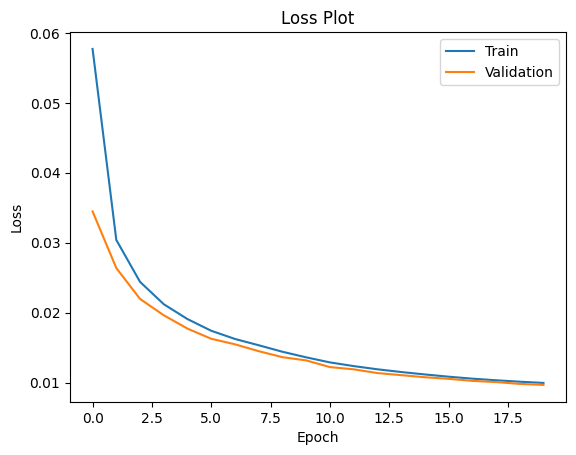

In [157]:
naive_autoencoder = Autoencoder(latent_dim=32, use_dropout=False)
train_model(naive_autoencoder, mode='naive')

  0%|          | 0/20 [00:00<?, ?it/s]

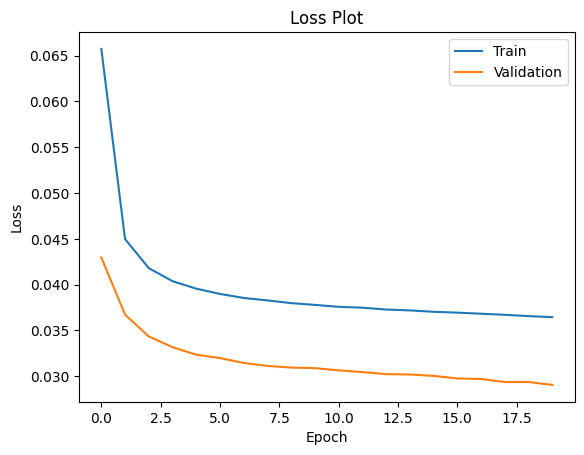

In [158]:
autoencoder_with_dropout = Autoencoder(latent_dim=32, use_dropout=True)
train_model(autoencoder_with_dropout, mode='naive')

  0%|          | 0/20 [00:00<?, ?it/s]

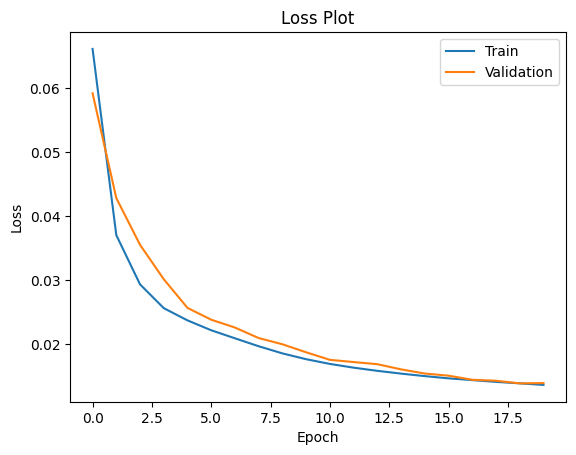

In [159]:
denoised_autoencoder = Autoencoder(latent_dim=32, use_dropout=False)  
train_model(denoised_autoencoder, mode='denoising', noise_factor=0.3)    # noise is added to training data inside train_mode() function

## Naive Autoencoder

Even with a bottleneck $m < d$, if the capacity of the encoder/decoder is high enough (many neurons or layers), the model can learn a complex mapping that specifically "overfits" the training distribution. It essentially learns a lookup table where specific combinations of latent neurons fire for specific training images, rather than learning the underlying manifold of the data.

Overfitting is visible when the **Training Loss continues to decrease** while the **Validation Loss begins to plateau or increase**. A large gap between the two curves indicates the model is failing to generalize to unseen data.

## Autoencoder with Dropout

During training, dropout randomly zeros out a fraction $p$ of the activations in a layer. This effectively forces the network to train on a different "thinned" architecture for every batch.

It reduces overfitting by preventing **co-adaptation** of neurons. A neuron cannot rely on the presence of another specific neuron to correct its errors. This forces every neuron to learn more robust, independent features that are useful across many sub-networks.

At test time, we want to use the full predictive power of the network, so we disable it. Since all neurons are active, we scale the weights (or activations) by $(1-p)$ to ensure the expected sum of activations remains consistent with what the model saw during training.

## Autoencoder with Noise Injection

A Denoising Autoencoder (DAE) cannot simply learn the identity function ($f(x)=x$). To reconstruct the clean $x$ from $\tilde{x}$, it must learn the structure of the data manifold to "pull" the noisy point back toward the closest point on the clean manifold. This forces it to capture the correlations between pixels (e.g., that pixels in a stroke of a '7' usually appear together).

Differences from Dropout:
* **Noise Injection:** Randomness is introduced at the **input layer** ($\tilde{x} = x + \epsilon$). It alters the data itself.
* **Dropout:** Randomness is introduced at the **hidden layers**. It alters the internal architecture and processing flow.

**Denoising Autoencoder** generalizes best. By forcing the model to reconstruct data from corrupted versions, we ensure it learns the "natural laws" of the dataset (e.g., the shape of a digit) rather than just pixel-perfect memorization. Dropout is a close second, acting as a general-purpose regularizer for any neural network.

In [ ]:
# TODO: part (e) Experimental Comparision on wandb